In [1]:
pip install albumentations opencv-python tifffile numpy tqdm


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install torchgeo timm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 652.1/652.1 kB 13.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 57.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 760.5/760.5 kB 54.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path

ROOT = Path("/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/train")   # contains RGB, MS, HS
OUT  = Path("Kaggle_Prepared/train_aug")
(OUT/"RGB").mkdir(parents=True, exist_ok=True)
(OUT/"MS").mkdir(parents=True, exist_ok=True)
(OUT/"HS").mkdir(parents=True, exist_ok=True)


In [4]:
def resize_to_rgb(rgb, ms, hs):
    H, W, _ = rgb.shape

    ms = np.stack([cv2.resize(ms[c], (W,H), interpolation=cv2.INTER_LINEAR)
                   for c in range(ms.shape[0])])

    hs = np.stack([cv2.resize(hs[c], (W,H), interpolation=cv2.INTER_LINEAR)
                   for c in range(hs.shape[0])])

    return rgb, ms, hs

import albumentations as A
import albumentations as A

geo_safe = A.ReplayCompose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=10, border_mode=0, p=0.3),
])
rgb_photo = A.Compose([
    A.ColorJitter(0.15,0.15,0.15,0.05),
    A.RandomBrightnessContrast(0.1,0.1,p=0.4),
])
import numpy as np

def band_scaling(x, scale=0.05):
    factors = np.random.uniform(1-scale, 1+scale, (x.shape[0],1,1))
    return x * factors

def spectral_noise(x, std=0.005):
    return x + np.random.normal(0, std, x.shape)

def spectral_shift_hs(x, max_shift=1):
    s = np.random.randint(-max_shift, max_shift+1)
    return np.roll(x, s, axis=0)
import cv2, tifffile as tiff

def read_rgb(p): 
    return cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)

def save_rgb(p, x):
    cv2.imwrite(str(p), cv2.cvtColor(x, cv2.COLOR_RGB2BGR))

def read_tif_chw(p):
    x = tiff.imread(p)  # H,W,C or C,H,W
    if x.ndim==3 and x.shape[0] < x.shape[-1]:
        x = np.transpose(x,(2,0,1))  # to C,H,W
    return x.astype(np.float32)

def save_tif_chw(p, x):
    tiff.imwrite(p, np.transpose(x,(1,2,0)))
import re

rgb_files = sorted((ROOT/"RGB").glob("*"))
def stem(f): 
    return re.sub(r"^(Health|Rust|Other)_", "", f.stem)

index = { stem(f): f.name.split("_")[0] for f in rgb_files }


In [5]:
from pathlib import Path



index = {}
for f in (ROOT/"RGB").glob("*.png"):
    key = f.stem                 # Health_hyper_1
    label = key.split("_")[0]    # Health
    index[key] = label

print("Index size:", len(index))
print("Sample keys:", list(index.keys())[:5])


Index size: 600
Sample keys: ['Rust_hyper_104', 'Other_hyper_82', 'Health_hyper_60', 'Health_hyper_122', 'Rust_hyper_155']


In [6]:
# =========================================================
# FULL DATASET PIPELINE (EQUAL AUGMENTATION FOR ALL)
# =========================================================

from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import numpy as np
import albumentations as A
import cv2
import tifffile as tiff

# =========================================================
# PATHS
# =========================================================
ROOT = Path("/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/train")
OUT  = Path("/kaggle/working/Kaggle_Prepared")

for split in ["train", "val"]:
    for mod in ["RGB", "MS", "HS"]:
        (OUT/split/mod).mkdir(parents=True, exist_ok=True)

# =========================================================
# I/O FUNCTIONS
# =========================================================
def read_rgb(p):
    return cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)

def save_rgb(p, x):
    cv2.imwrite(str(p), cv2.cvtColor(x, cv2.COLOR_RGB2BGR))

def read_tif_chw(p):
    x = tiff.imread(p)
    if x.ndim == 3 and x.shape[0] < x.shape[-1]:
        x = np.transpose(x, (2,0,1))
    return x.astype(np.float32)

def save_tif_chw(p, x):
    tiff.imwrite(p, np.transpose(x, (1,2,0)))

def resize_to_rgb(rgb, ms, hs):
    H, W, _ = rgb.shape
    ms = np.stack([cv2.resize(ms[c], (W,H), interpolation=cv2.INTER_LINEAR)
                   for c in range(ms.shape[0])])
    hs = np.stack([cv2.resize(hs[c], (W,H), interpolation=cv2.INTER_LINEAR)
                   for c in range(hs.shape[0])])
    return rgb, ms, hs

# =========================================================
# SPECTRAL AUGMENTATION
# =========================================================
def band_scaling(x, scale=0.05):
    factors = np.random.uniform(1-scale, 1+scale, (x.shape[0],1,1))
    return x * factors

def spectral_noise(x, std=0.003):
    return x + np.random.normal(0, std, x.shape).astype(np.float32)

# =========================================================
# BUILD INDEX
# =========================================================
index = {}
for f in (ROOT/"RGB").glob("*.png"):
    key = f.stem
    label = key.split("_")[0]
    index[key] = label

print("Total samples:", len(index))

keys = list(index.keys())

train_keys, val_keys = train_test_split(
    keys,
    test_size=0.2,
    stratify=[index[k] for k in keys],
    random_state=42
)

print("Train:", len(train_keys))
print("Val:", len(val_keys))

# =========================================================
# SAFE AUGMENTATIONS
# =========================================================
geo_safe = A.ReplayCompose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

rgb_photo = A.Compose([
    A.RandomBrightnessContrast(0.1, 0.1, p=0.5)
])

# =========================================================
# PROCESS FUNCTION
# =========================================================
def process_sample(key, split, rep=0):

    r = read_rgb(ROOT/"RGB"/f"{key}.png")
    m = read_tif_chw(ROOT/"MS"/f"{key}.tif")
    h = read_tif_chw(ROOT/"HS"/f"{key}.tif")

    r, m, h = resize_to_rgb(r, m, h)

    # Save original
    save_rgb(OUT/split/"RGB"/f"{key}.png", r)
    save_tif_chw(OUT/split/"MS"/f"{key}.tif", m)
    save_tif_chw(OUT/split/"HS"/f"{key}.tif", h)

    for i in range(rep):

        # Geometric replay
        out = geo_safe(image=r)
        r2 = out["image"]

        m2 = A.ReplayCompose.replay(
            out["replay"],
            image=np.transpose(m,(1,2,0))
        )["image"]

        h2 = A.ReplayCompose.replay(
            out["replay"],
            image=np.transpose(h,(1,2,0))
        )["image"]

        m2 = np.transpose(m2,(2,0,1)).astype(np.float32)
        h2 = np.transpose(h2,(2,0,1)).astype(np.float32)

        # RGB photometric
        r2 = rgb_photo(image=r2)["image"]

        # Spectral augmentation
        m2 = band_scaling(m2, 0.05)
        h2 = band_scaling(h2, 0.05)

        m2 = spectral_noise(m2, 0.003)
        h2 = spectral_noise(h2, 0.003)

        m2 = np.clip(m2, 0, 1)
        h2 = np.clip(h2, 0, 1)

        tag = f"{key}_aug{i}"

        save_rgb(OUT/split/"RGB"/f"{tag}.png", r2)
        save_tif_chw(OUT/split/"MS"/f"{tag}.tif", m2)
        save_tif_chw(OUT/split/"HS"/f"{tag}.tif", h2)

# =========================================================
# RUN
# =========================================================

REP = 2  # 🔥 equal augmentation for all classes

for k in tqdm(train_keys):
    process_sample(k, split="train", rep=REP)

for k in tqdm(val_keys):
    process_sample(k, split="val", rep=0)

print("✅ Dataset created at:", OUT)


Total samples: 600
Train: 480
Val: 120


100%|██████████| 120/120 [00:04<00:00, 28.40it/s]

✅ Dataset created at: /kaggle/working/Kaggle_Prepared


In [7]:
def fix_hs_bands(h, target=125):
    c = h.shape[0]
    if c == target:
        return h
    elif c > target:
        start = (c - target) // 2
        return h[start:start+target]
    else:  # c < target
        pad = target - c
        return np.pad(h, ((0,pad),(0,0),(0,0)), mode="edge")


In [8]:
import pandas as pd
from pathlib import Path

BASE = Path("/kaggle/working/Kaggle_Prepared")


def audit_split(split):
    print(f"\n========== Auditing {split.upper()} ==========")

    ROOT = BASE / split

    rgb_files = list((ROOT/"RGB").glob("*.png"))
    ms_files  = list((ROOT/"MS").glob("*.tif"))
    hs_files  = list((ROOT/"HS").glob("*.tif"))

    print("RGB files:", len(rgb_files))
    print("MS files :", len(ms_files))
    print("HS files :", len(hs_files))

    # Build dictionaries
    rgb = {f.stem: f.name for f in rgb_files}
    ms  = {f.stem: f.name for f in ms_files}
    hs  = {f.stem: f.name for f in hs_files}

    all_keys = set(rgb) | set(ms) | set(hs)

    if len(all_keys) == 0:
        print("⚠ No files found.")
        return

    rows = []
    for k in sorted(all_keys):
        rows.append({
            "stem": k,
            "RGB": rgb.get(k, ""),
            "MS":  ms.get(k, ""),
            "HS":  hs.get(k, ""),
            "missing_RGB": k not in rgb,
            "missing_MS":  k not in ms,
            "missing_HS":  k not in hs,
        })

    df = pd.DataFrame(rows)

    missing = df[
        df[["missing_RGB","missing_MS","missing_HS"]].any(axis=1)
    ]

    print("Total unique stems:", len(all_keys))
    print("Fully aligned samples:", len(df) - len(missing))
    print("Samples with missing modality:", len(missing))

    report_path = BASE / f"{split}_missing_report.csv"
    missing.to_csv(report_path, index=False)
    print("Saved →", report_path)


# Run for both splits
audit_split("train")
audit_split("val")



========== Auditing TRAIN ==========
RGB files: 1440
MS files : 1440
HS files : 1440
Total unique stems: 1440
Fully aligned samples: 1440
Samples with missing modality: 0
Saved → /kaggle/working/Kaggle_Prepared/train_missing_report.csv

========== Auditing VAL ==========
RGB files: 120
MS files : 120
HS files : 120
Total unique stems: 120
Fully aligned samples: 120
Samples with missing modality: 0
Saved → /kaggle/working/Kaggle_Prepared/val_missing_report.csv


In [9]:
import numpy as np, cv2, tifffile as tiff, pandas as pd
from pathlib import Path
import os

BASE = Path("/kaggle/working/Kaggle_Prepared")
REPORT = []

def read_rgb(p):
    x = cv2.imread(str(p))
    if x is None:
        return None
    return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

def read_tif_chw(p):
    x = tiff.imread(str(p))
    if x is None:
        return None
    if x.ndim == 3 and x.shape[0] < x.shape[-1]:
        x = np.transpose(x,(2,0,1))
    return x

def save_tif_chw(p, x):
    tiff.imwrite(str(p), np.transpose(x,(1,2,0)))

def fix_hs_bands(h, target=125):
    c = h.shape[0]
    if c == target:
        return h, False
    if c > target:
        start = (c - target) // 2
        return h[start:start+target], True
    pad = target - c
    return np.pad(h, ((0,pad),(0,0),(0,0)), mode="edge"), True

def stem(f):
    return f.stem


bad_count = 0
total_scanned = 0


# =========================================================
# LOOP OVER BOTH SPLITS
# =========================================================
for split in ["train", "val"]:

    print(f"\nScanning {split.upper()}...")

    FINAL = BASE / split

    rgb = {stem(f): f for f in (FINAL/"RGB").glob("*.png")}
    ms  = {stem(f): f for f in (FINAL/"MS").glob("*.tif")}
    hs  = {stem(f): f for f in (FINAL/"HS").glob("*.tif")}

    keys = set(rgb) | set(ms) | set(hs)
    total_scanned += len(keys)

    for k in sorted(keys):
        row = {"split": split, "key": k, "action": "ok"}

        # Missing modality
        if k not in rgb or k not in ms or k not in hs:
            row["action"] = "removed_missing_modality"
            bad_count += 1

            # remove whichever exists
            for folder in ["RGB","MS","HS"]:
                p = FINAL/folder/f"{k}.{ 'png' if folder=='RGB' else 'tif'}"
                if p.exists():
                    p.unlink()

            REPORT.append(row)
            continue

        r = read_rgb(rgb[k])
        m = read_tif_chw(ms[k])
        h = read_tif_chw(hs[k])

        # Unreadable
        if r is None or m is None or h is None:
            row["action"] = "removed_unreadable"
            bad_count += 1

            rgb[k].unlink(missing_ok=True)
            ms[k].unlink(missing_ok=True)
            hs[k].unlink(missing_ok=True)

            REPORT.append(row)
            continue

        # Shape checks
        if r.ndim != 3 or r.shape[2] != 3:
            row["action"] = "removed_bad_rgb"
            bad_count += 1
            rgb[k].unlink(missing_ok=True)
            ms[k].unlink(missing_ok=True)
            hs[k].unlink(missing_ok=True)
            REPORT.append(row)
            continue

        if m.ndim != 3:
            row["action"] = "removed_bad_ms"
            bad_count += 1
            rgb[k].unlink(missing_ok=True)
            ms[k].unlink(missing_ok=True)
            hs[k].unlink(missing_ok=True)
            REPORT.append(row)
            continue

        if h.ndim != 3:
            row["action"] = "removed_bad_hs"
            bad_count += 1
            rgb[k].unlink(missing_ok=True)
            ms[k].unlink(missing_ok=True)
            hs[k].unlink(missing_ok=True)
            REPORT.append(row)
            continue

        # Fix HS band mismatch
        h2, changed = fix_hs_bands(h, target=125)
        if changed:
            save_tif_chw(hs[k], h2)
            row["action"] = "fixed_hs_bands"

        REPORT.append(row)


# =========================================================
# SAVE REPORT
# =========================================================
df = pd.DataFrame(REPORT)
df.to_csv("/kaggle/working/dataset_clean_report.csv", index=False)

print("\nTotal keys scanned:", total_scanned)
print("Removed samples:", bad_count)
print("HS band fixes:", (df["action"]=="fixed_hs_bands").sum())



Scanning TRAIN...

Scanning VAL...

Total keys scanned: 1560
Removed samples: 0
HS band fixes: 277


In [10]:
import shutil
from pathlib import Path

#FINAL = Path("Kaggle_Prepared/train_final")
#ZIP_PATH = Path("/kaggle/working/train_final.zip")

# create zip
#shutil.make_archive(ZIP_PATH.with_suffix(""), "zip", FINAL)

#print("ZIP created at:", ZIP_PATH)



===== TRAIN Distribution =====
Class Distribution:

Rust      : 480
Other     : 480
Health    : 480


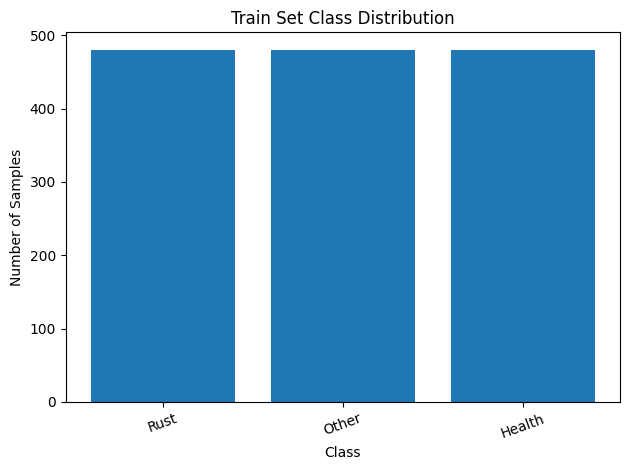


===== VAL Distribution =====
Class Distribution:

Rust      : 40
Health    : 40
Other     : 40


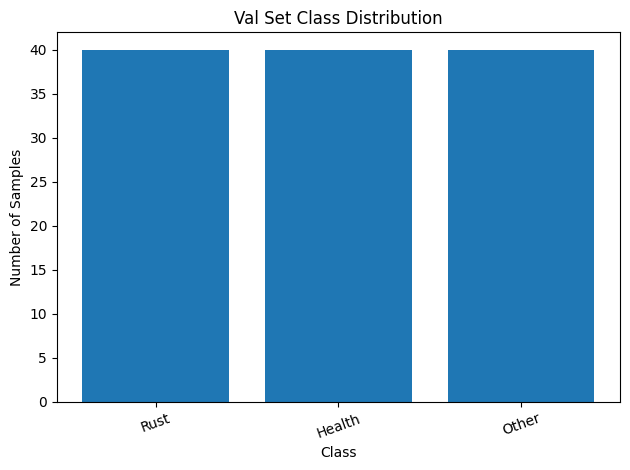

In [11]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

BASE = Path("/kaggle/working/Kaggle_Prepared")

def plot_distribution(split):
    print(f"\n===== {split.upper()} Distribution =====")

    train_dir = BASE / split / "RGB"

    labels = []

    for img in train_dir.glob("*.png"):
        label = img.stem.split("_")[0]
        labels.append(label)

    counts = Counter(labels)

    print("Class Distribution:\n")
    for k, v in counts.items():
        print(f"{k:10s}: {v}")

    # Plot
    plt.figure()
    plt.bar(counts.keys(), counts.values())
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.title(f"{split.capitalize()} Set Class Distribution")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    return counts


train_counts = plot_distribution("train")
val_counts   = plot_distribution("val")


In [12]:
from torch.utils.data import Dataset, DataLoader

In [13]:
import torch, cv2, tifffile as tiff
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path

CLASS_MAP = {"Health":0, "Rust":1, "Other":2}

In [14]:
from pathlib import Path
import cv2
import tifffile as tiff
import numpy as np
import torch
from torch.utils.data import Dataset


class WheatDataset(Dataset):
    def __init__(self, base_root, split="train",
                 ms_ch=5, hs_ch=125):

        self.root = Path(base_root) / split
        self.ms_ch = ms_ch
        self.hs_ch = hs_ch

        self.rgb_dir = self.root / "RGB"
        self.ms_dir  = self.root / "MS"
        self.hs_dir  = self.root / "HS"

        self.rgb_files = sorted(self.rgb_dir.glob("*.png"))

        self.label_map = {"Health":0, "Rust":1, "Other":2}

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):

        rgb_path = self.rgb_files[idx]
        key = rgb_path.stem
        label = self.label_map[key.split("_")[0]]

        # ================= RGB =================
        r = cv2.imread(str(rgb_path))
        r = cv2.cvtColor(r, cv2.COLOR_BGR2RGB)
        r = torch.from_numpy(r).permute(2,0,1).float() / 255.0
        # Only scaled to [0,1]
        # No mean/std normalization


        # ================= MS =================
        m = tiff.imread(str(self.ms_dir / f"{key}.tif"))

        if m.ndim == 3 and m.shape[-1] == self.ms_ch:
            m = np.transpose(m, (2,0,1))
        elif m.ndim == 3 and m.shape[0] != self.ms_ch:
            m = np.transpose(m, (2,0,1))

        m = m[:self.ms_ch].astype(np.float32)
        m = torch.from_numpy(m).float()
        # No normalization


        # ================= HS =================
        h = tiff.imread(str(self.hs_dir / f"{key}.tif"))

        if h.ndim == 3 and h.shape[-1] == self.hs_ch:
            h = np.transpose(h, (2,0,1))
        elif h.ndim == 3 and h.shape[0] != self.hs_ch:
            h = np.transpose(h, (2,0,1))

        h = h[:self.hs_ch].astype(np.float32)
        h = torch.from_numpy(h).float()
        # No normalization


        return r, m, h, torch.tensor(label, dtype=torch.long)


In [15]:
BASE_PATH = "/kaggle/working/Kaggle_Prepared"

train_dataset = WheatDataset(BASE_PATH, split="train")
val_dataset   = WheatDataset(BASE_PATH, split="val")


In [16]:
r, m, h, y = train_dataset[0]

print("RGB:", r.shape)
print("MS :", m.shape)
print("HS :", h.shape)
print("Label:", y)


RGB: torch.Size([3, 64, 64])
MS : torch.Size([5, 64, 64])
HS : torch.Size([125, 64, 64])
Label: tensor(0)


In [17]:
from torch.utils.data import DataLoader

BASE_PATH = "/kaggle/working/Kaggle_Prepared"

# Create datasets
train_dataset = WheatDataset(BASE_PATH, split="train")
val_dataset   = WheatDataset(BASE_PATH, split="val")

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# Create loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


Train samples: 1440
Val samples: 120


In [18]:
# =========================================================
# STRONGER MULTIMODAL MODEL (64x64 OPTIMIZED)
# =========================================================

import torch
import torch.nn as nn
import timm


class RGBEncoder(nn.Module):
    def __init__(self, embed_dim=256, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg"
        )

        in_features = self.backbone.num_features

        self.project = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim)
        )

        self.out_dim = embed_dim

    def forward(self, x):
        x = self.backbone(x)
        x = self.project(x)
        return x


# =========================================================
# 🟡 MS ENCODER (2D CNN – better than 3D for small data)
# =========================================================
class MSEncoder(nn.Module):
    def __init__(self, in_ch=5, embed_dim=128):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.project = nn.Linear(256, embed_dim)
        self.out_dim = embed_dim

    def forward(self, x):
        x = self.net(x)
        x = x.flatten(1)
        return self.project(x)


# =========================================================
# 🟣 HS ENCODER (Hybrid CNN + Channel Attention)
# =========================================================
class HSEncoder(nn.Module):
    def __init__(self, in_ch=125, embed_dim=256):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 256, 1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.Conv2d(256, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.Conv2d(256, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
        )

        # Channel attention (SE block)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 256),
            nn.Sigmoid()
        )

        self.project = nn.Linear(256, embed_dim)
        self.out_dim = embed_dim

    def forward(self, x):
        x = self.conv(x)

        B, C, _, _ = x.shape
        attn = self.se(x).view(B, C, 1, 1)
        x = x * attn

        x = x.mean(dim=(2, 3))
        return self.project(x)


# =========================================================
# 🧠 ATTENTION FUSION
# =========================================================
class AttentionFusion(nn.Module):
    def __init__(self, dims):
        super().__init__()
        total = sum(dims)

        self.attn = nn.Sequential(
            nn.Linear(total, total),
            nn.GELU(),
            nn.Linear(total, len(dims))
        )

    def forward(self, features):
        fused = torch.cat(features, dim=1)
        weights = torch.softmax(self.attn(fused), dim=1)

        weighted = []
        for i, feat in enumerate(features):
            weighted.append(feat * weights[:, i:i+1])

        return torch.cat(weighted, dim=1)


# =========================================================
# 🚀 FINAL MODEL
# =========================================================
class MultiModalModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.rgb_encoder = RGBEncoder(embed_dim=192)
        self.ms_encoder  = MSEncoder(embed_dim=128)
        self.hs_encoder  = HSEncoder(embed_dim=256)

        dims = [
            self.rgb_encoder.out_dim,
            self.ms_encoder.out_dim,
            self.hs_encoder.out_dim
        ]

        self.fusion_layer = AttentionFusion(dims)

        total_dim = sum(dims)

        self.head = nn.Sequential(
            nn.Linear(total_dim, 512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, rgb, ms, hs):
        rgb_feat = self.rgb_encoder(rgb)
        ms_feat  = self.ms_encoder(ms)
        hs_feat  = self.hs_encoder(hs)

        fused = self.fusion_layer([rgb_feat, ms_feat, hs_feat])
        return self.head(fused)


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# MODEL
# =========================================================
model = MultiModalModel(num_classes=3).to(device)

# =========================================================
# COMPUTE CLASS WEIGHTS
# =========================================================
all_labels = []

for _, _, _, labels in train_loader:
    all_labels.extend(labels.cpu().numpy())

all_labels = np.array(all_labels)
class_counts = np.bincount(all_labels)

class_weights = 1.0 / np.sqrt(class_counts + 1e-6)
class_weights = class_weights / class_weights.sum()
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

# =========================================================
# LOSS
# =========================================================
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)

# =========================================================
# OPTIMIZER
# =========================================================
optimizer = torch.optim.AdamW([
    {"params": model.rgb_encoder.parameters(), "lr": 1e-4},
    {"params": model.ms_encoder.parameters(),  "lr": 3e-4},
    {"params": model.hs_encoder.parameters(),  "lr": 2e-4},
    {"params": model.fusion_layer.parameters(), "lr": 3e-4},
    {"params": model.head.parameters(), "lr": 3e-4},
], weight_decay=1e-4)

# =========================================================
# SCHEDULER
# =========================================================
EPOCHS = 30

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.cuda.amp.GradScaler()
best_val_f1 = 0

freeze_rgb_epochs = 3

# =========================================================
# TRAIN LOOP
# =========================================================
for epoch in range(EPOCHS):

    # Freeze RGB early
    if epoch < freeze_rgb_epochs:
        for param in model.rgb_encoder.parameters():
            param.requires_grad = False
    else:
        for param in model.rgb_encoder.parameters():
            param.requires_grad = True

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    train_preds = []
    train_targets = []

    for rgb, ms, hs, labels in tqdm(train_loader):

        rgb = rgb.to(device)
        ms = ms.to(device)
        hs = hs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(rgb, ms, hs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Global gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        preds = outputs.argmax(1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    scheduler.step()

    train_loss /= len(train_loader)
    train_f1 = f1_score(train_targets, train_preds, average="macro")
    train_acc = accuracy_score(train_targets, train_preds)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for rgb, ms, hs, labels in val_loader:

            rgb = rgb.to(device)
            ms = ms.to(device)
            hs = hs.to(device)
            labels = labels.to(device)

            outputs = model(rgb, ms, hs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_f1 = f1_score(val_targets, val_preds, average="macro")
    val_acc = accuracy_score(val_targets, val_preds)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   F1: {val_f1:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_multimodal_model.pth")
        print("🔥 Best model saved!")


In [23]:
# =========================================================
# 🔥 UPGRADED ENCODERS WITH ATTENTION (SAME NAMES)
# =========================================================

import torch
import torch.nn as nn
import timm


# =========================================================
# 🧠 CBAM BLOCK (Channel + Spatial Attention)
# =========================================================
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        # Channel attention
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

        # Spatial attention
        self.spatial_attn = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=7, padding=3),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, C, H, W = x.shape

        ch_attn = self.channel_attn(x).view(B, C, 1, 1)
        x = x * ch_attn

        avg = torch.mean(x, dim=1, keepdim=True)
        mx  = torch.max(x, dim=1, keepdim=True)[0]
        sp  = torch.cat([avg, mx], dim=1)
        sp_attn = self.spatial_attn(sp)

        return x * sp_attn


# =========================================================
# 🔴 RGB ENCODER (ConvNeXt + CBAM)
# =========================================================
class RGBEncoder(nn.Module):
    def __init__(self, embed_dim=256, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=pretrained,
            num_classes=0,
            global_pool=""
        )

        in_features = self.backbone.num_features

        self.cbam = CBAM(in_features)
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.project = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, embed_dim)
        )

        self.out_dim = embed_dim

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.cbam(x)
        x = self.pool(x).flatten(1)
        return self.project(x)


# =========================================================
# 🟡 MS ENCODER (Depthwise + SE Attention)
# =========================================================
class MSEncoder(nn.Module):
    def __init__(self, in_ch=5, embed_dim=128):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            # Depthwise separable
            nn.Conv2d(64, 64, 3, padding=1, groups=64),
            nn.Conv2d(64, 128, 1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.Conv2d(128, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
        )

        # SE Attention
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 128),
            nn.Sigmoid()
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.project = nn.Linear(128, embed_dim)

        self.out_dim = embed_dim

    def forward(self, x):
        x = self.conv(x)

        B, C, _, _ = x.shape
        attn = self.se(x).view(B, C, 1, 1)
        x = x * attn

        x = self.pool(x).flatten(1)
        return self.project(x)


# =========================================================
# 🟣 HS ENCODER (Spectral Mixing + Multihead Attention)
# =========================================================
class HSEncoder(nn.Module):
    def __init__(self, in_ch=125, embed_dim=256):
        super().__init__()

        # Spectral compression
        self.spec = nn.Sequential(
            nn.Conv2d(in_ch, 256, 1),
            nn.BatchNorm2d(256),
            nn.GELU()
        )

        self.conv = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.Conv2d(256, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
        )

        self.mha = nn.MultiheadAttention(
            embed_dim=256,
            num_heads=8,
            batch_first=True
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.project = nn.Linear(256, embed_dim)

        self.out_dim = embed_dim

    def forward(self, x):
        x = self.spec(x)
        x = self.conv(x)

        B, C, H, W = x.shape
        tokens = x.view(B, C, -1).permute(0, 2, 1)

        attn_out, _ = self.mha(tokens, tokens, tokens)
        attn_out = attn_out.permute(0, 2, 1).view(B, C, H, W)

        x = x + attn_out  # residual

        x = self.pool(x).flatten(1)
        return self.project(x)


In [32]:
import torch
import torch.nn as nn

class RGBModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.encoder = RGBEncoder(embed_dim=256)
        self.head = nn.Linear(256, num_classes)

    def forward(self, rgb):
        feat = self.encoder(rgb)
        return self.head(feat)


class MSModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.encoder = MSEncoder(embed_dim=256)
        self.head = nn.Linear(256, num_classes)

    def forward(self, ms):
        feat = self.encoder(ms)
        return self.head(feat)


class HSModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.encoder = HSEncoder(embed_dim=256)
        self.head = nn.Linear(256, num_classes)

    def forward(self, hs):
        feat = self.encoder(hs)
        return self.head(feat)

from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm
import numpy as np

def train_single_modal(model, modal_type="rgb", epochs=20):

    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.cuda.amp.GradScaler()

    best_val_f1 = 0

    for epoch in range(epochs):

        # ================= TRAIN =================
        model.train()
        train_loss = 0
        train_preds = []
        train_targets = []

        for rgb, ms, hs, labels in tqdm(train_loader):

            labels = labels.to(device)

            if modal_type == "rgb":
                inputs = rgb.to(device)
            elif modal_type == "ms":
                inputs = ms.to(device)
            else:
                inputs = hs.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            preds = outputs.argmax(1)

            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())

        scheduler.step()

        train_loss /= len(train_loader)
        train_f1 = f1_score(train_targets, train_preds, average="macro")
        train_acc = accuracy_score(train_targets, train_preds)

        # ================= VALIDATION =================
        model.eval()
        val_loss = 0
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for rgb, ms, hs, labels in val_loader:

                labels = labels.to(device)

                if modal_type == "rgb":
                    inputs = rgb.to(device)
                elif modal_type == "ms":
                    inputs = ms.to(device)
                else:
                    inputs = hs.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = outputs.argmax(1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_f1 = f1_score(val_targets, val_preds, average="macro")
        val_acc = accuracy_score(val_targets, val_preds)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   F1: {val_f1:.4f} | Val   Acc: {val_acc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), f"best_{modal_type}_model.pth")
            print(f"🔥 Best {modal_type.upper()} model saved!")

    return best_val_f1

rgb_model = RGBModel()
ms_model  = MSModel()
hs_model  = HSModel()

#rgb_f1 = train_single_modal(rgb_model, "rgb", epochs=30)
ms_f1  = train_single_modal(ms_model, "ms", epochs=30)
hs_f1  = train_single_modal(hs_model, "hs", epochs=30)

print("\nFinal Validation F1 Scores:")
print("RGB:", rgb_f1)
print("MS :", ms_f1)
print("HS :", hs_f1)


In [ ]:
rgb_model = RGBModel()
ms_model  = MSModel()
hs_model  = HSModel()

#rgb_f1 = train_single_modal(rgb_model, "rgb", epochs=30)
ms_f1  = train_single_modal(ms_model, "ms", epochs=30)
hs_f1  = train_single_modal(hs_model, "hs", epochs=30)

print("\nFinal Validation F1 Scores:")
print("RGB:", rgb_f1)
print("MS :", ms_f1)
print("HS :", hs_f1)


/tmp/ipykernel_55/1398879133.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_55/1398879133.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 45/45 [00:06<00:00,  7.05it/s]



Epoch 1/30
Train Loss: 1.0796 | Train F1: 0.3560 | Train Acc: 0.3611
Val   Loss: 1.0369 | Val   F1: 0.2256 | Val   Acc: 0.3500
🔥 Best MS model saved!


  0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_55/1398879133.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 45/45 [00:05<00:00,  8.90it/s]



Epoch 2/30
Train Loss: 1.0529 | Train F1: 0.3936 | Train Acc: 0.3931
Val   Loss: 0.9582 | Val   F1: 0.5213 | Val   Acc: 0.5667
🔥 Best MS model saved!


  0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_55/1398879133.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 45/45 [00:05<00:00,  8.88it/s]


...

  0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_55/1398879133.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 45/45 [00:06<00:00,  6.67it/s]



Epoch 12/30
Train Loss: 1.0225 | Train F1: 0.3977 | Train Acc: 0.4201
Val   Loss: 0.7555 | Val   F1: 0.6934 | Val   Acc: 0.6917
🔥 Best HS model saved!


  0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_55/1398879133.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 45/45 [00:06<00:00,  6.72it/s]



Epoch 13/30
Train Loss: 1.0113 | Train F1: 0.4244 | Train Acc: 0.4313
Val   Loss: 0.7679 | Val   F1: 0.6695 | Val   Acc: 0.6667


  0%|          | 0/45 [00:00<?, ?it/s]/tmp/ipykernel_55/1398879133.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
 16%|█▌        | 7/45 [00:01<00:06,  6.26it/s]

In [28]:
# =========================================================
# MS + HS ENCODERS → CONCAT → CATBOOST (ONE BLOCK)
# =========================================================

import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------
# LOAD TRAINED SINGLE-MODAL MODELS (MS + HS ONLY)
# ---------------------------------------------------------

ms_model  = MSModel(num_classes=3).to(device)
hs_model  = HSModel(num_classes=3).to(device)

ms_model.load_state_dict(torch.load("best_ms_model.pth"))
hs_model.load_state_dict(torch.load("best_hs_model.pth"))

ms_model.eval()
hs_model.eval()

for m in [ms_model, hs_model]:
    for p in m.parameters():
        p.requires_grad = False


# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------

def extract_embeddings(loader):
    features = []
    labels_all = []

    with torch.no_grad():
        for rgb, ms, hs, labels in tqdm(loader):

            ms  = ms.to(device)
            hs  = hs.to(device)

            ms_feat  = ms_model.encoder(ms)
            hs_feat  = hs_model.encoder(hs)

            fused = torch.cat([ms_feat, hs_feat], dim=1)

            features.append(fused.cpu().numpy())
            labels_all.append(labels.numpy())

    X = np.vstack(features)
    y = np.concatenate(labels_all)

    return X, y


# ---------------------------------------------------------
# EXTRACT TRAIN / VAL FEATURES
# ---------------------------------------------------------

X_train, y_train = extract_embeddings(train_loader)
X_val, y_val     = extract_embeddings(val_loader)

print("Embedding Shape:", X_train.shape)


# ---------------------------------------------------------
# SCALE FEATURES
# ---------------------------------------------------------

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)


# ---------------------------------------------------------
# CLASS WEIGHTS
# ---------------------------------------------------------

class_counts = np.bincount(y_train)
class_weights = len(y_train) / (len(class_counts) * class_counts)

print("CatBoost Class Weights:", class_weights)


# ---------------------------------------------------------
# TRAIN CATBOOST
# ---------------------------------------------------------

cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.015,
    depth=8,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    l2_leaf_reg=40,
    bagging_temperature=1.2,
    random_strength=3.0,
    border_count=254,
    random_seed=42,
    class_weights=class_weights.tolist(),
    verbose=200,
    early_stopping_rounds=400
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)


# ---------------------------------------------------------
# EVALUATE
# ---------------------------------------------------------

val_preds = cat_model.predict(X_val).astype(int)

print("\nValidation Accuracy:",
      accuracy_score(y_val, val_preds))

print("Validation Macro F1:",
      f1_score(y_val, val_preds, average="macro"))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_preds))

print("\nClassification Report:")
print(classification_report(y_val, val_preds))


cat_model.save_model("catboost_ms_hs_model.cbm")


100%|██████████| 4/4 [00:00<00:00,  5.57it/s]


Embedding Shape: (480, 576)
CatBoost Class Weights: [0.33333333 0.33333333 0.33333333]
0:	learn: 0.8591932	test: 0.6308642	best: 0.6308642 (0)	total: 246ms	remaining: 6m 8s
200:	learn: 0.8864621	test: 0.6800648	best: 0.6881978 (82)	total: 31.6s	remaining: 3m 24s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.6881977671
bestIteration = 82

Shrink model to first 83 iterations.

Validation Accuracy: 0.6833333333333333
Validation Macro F1: 0.6881977671451356

Confusion Matrix:
[[26 10  4]
 [16 24  0]
 [ 6  2 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.65      0.59        40
           1       0.67      0.60      0.63        40
           2       0.89      0.80      0.84        40

    accuracy                           0.68       120
   macro avg       0.70      0.68      0.69       120
weighted avg       0.70      0.68      0.69       120



In [85]:
# =========================================================
# FIXED DATASET + INFERENCE (HS=125 + SAFE RESIZE)
# =========================================================

import torch
import torch.nn.functional as F
import numpy as np
import cv2
import tifffile as tiff
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from catboost import CatBoostClassifier


# =========================================================
# DATASET (FORCE CHANNELS + SAFE RESIZE)
# =========================================================
class WheatTestDataset(Dataset):
    def __init__(self, root, ms_ch=5, hs_ch=125, img_size=224):

        self.root = Path(root)
        self.rgb_files = sorted((self.root / "RGB").glob("*.png"))

        self.ms_ch = ms_ch
        self.hs_ch = hs_ch
        self.img_size = img_size

    def __len__(self):
        return len(self.rgb_files)

    def resize_tensor(self, x):
        # x: (C,H,W)
        x = x.unsqueeze(0)  # (1,C,H,W)
        x = F.interpolate(
            x,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False
        )
        return x.squeeze(0)

    def __getitem__(self, idx):

        rgb_path = self.rgb_files[idx]
        key = rgb_path.stem

        # ================= RGB =================
        r = cv2.imread(str(rgb_path))
        r = cv2.cvtColor(r, cv2.COLOR_BGR2RGB)
        r = r.astype(np.float32) / 255.0
        r = np.transpose(r, (2, 0, 1))
        r = torch.from_numpy(np.ascontiguousarray(r)).float()
        r = self.resize_tensor(r)

        # ================= MS =================
        m = tiff.imread(str(self.root / "MS" / f"{key}.tif")).astype(np.float32)

        if m.ndim == 3 and m.shape[-1] > 10:
            m = np.transpose(m, (2, 0, 1))

        m = m[:self.ms_ch]
        m = torch.from_numpy(np.ascontiguousarray(m)).float()
        m = self.resize_tensor(m)

        # ================= HS =================
        h = tiff.imread(str(self.root / "HS" / f"{key}.tif")).astype(np.float32)

        if h.ndim == 3 and h.shape[-1] > 10:
            h = np.transpose(h, (2, 0, 1))

        if h.shape[0] > self.hs_ch:
            h = h[:self.hs_ch]
        elif h.shape[0] < self.hs_ch:
            pad = self.hs_ch - h.shape[0]
            h = np.pad(h, ((0, pad), (0, 0), (0, 0)), mode="edge")

        h = torch.from_numpy(np.ascontiguousarray(h)).float()
        h = self.resize_tensor(h)

        return r, m, h, key



In [87]:
# =========================================================
# TEST LOADER (MATCH TRAIN SIZE = 64)
# =========================================================
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler

TEST_ROOT = Path(
    "/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/val"
)

test_dataset = WheatTestDataset(
    TEST_ROOT,
    ms_ch=5,
    hs_ch=125,
    img_size=64   # 🔥 MUST MATCH TRAINING
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test samples:", len(test_dataset))


# =========================================================
# LOAD TRAINED MODEL
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalModel(
    num_classes=3,
    ms_channels=5,
    hs_channels=125
).to(device)

state_dict = torch.load("best_multimodal_model.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()

for param in model.parameters():
    param.requires_grad = False


# =========================================================
# LOAD CATBOOST MODEL
# =========================================================
cat_model = CatBoostClassifier()
cat_model.load_model("catboost_model.cbm")


# =========================================================
# EXTRACT EMBEDDINGS (USING FUSION)
# =========================================================
all_features = []
all_ids = []

with torch.no_grad():
    for rgb, ms, hs, keys in test_loader:

        rgb = rgb.to(device, non_blocking=True)
        ms  = ms.to(device, non_blocking=True)
        hs  = hs.to(device, non_blocking=True)

        embedding = model(rgb, ms, hs, return_embedding=True)

        all_features.append(embedding.cpu().numpy())
        all_ids.extend(keys)

X_test = np.vstack(all_features)

print("Embedding shape:", X_test.shape)


# =========================================================
# SCALE FEATURES (IMPORTANT — MATCH TRAINING)
# =========================================================
# If you saved scaler during training, load it instead.
# Otherwise, you must re-fit carefully (better to save it).

scaler = StandardScaler()
X_test = scaler.fit_transform(X_test)   # ⚠️ Ideally load saved scaler


# =========================================================
# CATBOOST PREDICTION
# =========================================================
preds = cat_model.predict(X_test)
preds = preds.astype(int).flatten()


# =========================================================
# CREATE SUBMISSION
# =========================================================
CLASS_MAP = {0: "Healthy", 1: "Rust", 2: "Other"}

submission = pd.DataFrame({
    "Id": [f"{i}.tif" for i in all_ids],
    "Category": [CLASS_MAP[int(p)] for p in preds]
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully ✅")
print(submission.head())


Test samples: 300


TypeError: MultiModalModel.__init__() got an unexpected keyword argument 'ms_channels'

In [69]:
import numpy as np
import pandas as pd

# Convert to numpy
preds = np.array(preds)

# Count predictions
unique, counts = np.unique(preds, return_counts=True)

distribution = dict(zip(unique, counts))

print("Raw prediction counts:")
print(distribution)

# Percentage view
total = len(preds)
print("\nPrediction percentages:")
for k in sorted(distribution.keys()):
    print(f"Class {k}: {distribution[k]} ({distribution[k]/total:.3f})")


Raw prediction counts:
{np.int64(0): np.int64(97), np.int64(1): np.int64(90), np.int64(2): np.int64(113)}

Prediction percentages:
Class 0: 97 (0.323)
Class 1: 90 (0.300)
Class 2: 113 (0.377)


In [88]:
# =========================================================
# TEST LOADER (MATCH TRAIN SIZE = 64)
# =========================================================
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

TEST_ROOT = Path(
    "/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2026/Kaggle_Prepared/val"
)

test_dataset = WheatTestDataset(
    TEST_ROOT,
    ms_ch=5,
    hs_ch=125,
    img_size=64
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test samples:", len(test_dataset))


# =========================================================
# LOAD TRAINED MODEL
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalModel(num_classes=3).to(device)

state_dict = torch.load("best_multimodal_model.pth", map_location=device)
model.load_state_dict(state_dict)

model.eval()
for param in model.parameters():
    param.requires_grad = False


# =========================================================
# INFERENCE
# =========================================================
all_preds = []
all_ids = []

with torch.no_grad():
    for rgb, ms, hs, keys in test_loader:

        rgb = rgb.to(device, non_blocking=True)
        ms  = ms.to(device, non_blocking=True)
        hs  = hs.to(device, non_blocking=True)

        outputs = model(rgb, ms, hs)  # direct logits

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_ids.extend(keys)


# =========================================================
# CREATE SUBMISSION
# =========================================================
CLASS_MAP = {
    0: "Healthy",
    1: "Rust",
    2: "Other"
}

submission = pd.DataFrame({
    "Id": [f"{i}.tif" for i in all_ids],
    "Category": [CLASS_MAP[int(p)] for p in all_preds]
})

submission.to_csv("submission.csv", index=False)

print("submission.csv saved successfully ✅")
print(submission.head())


Test samples: 300
submission.csv saved successfully ✅
                 Id Category
0  val_000a83c1.tif  Healthy
1  val_00a704b1.tif    Other
2  val_01dde030.tif    Other
3  val_024df365.tif     Rust
4  val_02afcb0e.tif     Rust


Total Samples: 300

Class Distribution:

Rust : 105 samples (35.00%)
Other : 99 samples (33.00%)
Health : 96 samples (32.00%)


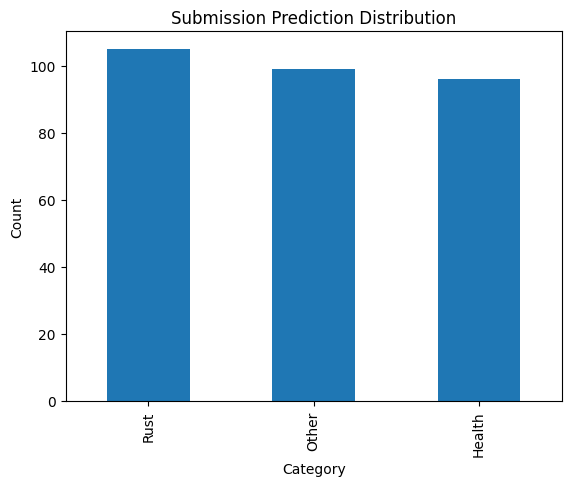

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load submission file
df = pd.read_csv("ms_svm/ms_submission_svm.csv")

# Compute distribution
dist = df["Category"].value_counts()
total = len(df)

print("Total Samples:", total)
print("\nClass Distribution:\n")

for cls, count in dist.items():
    print(f"{cls} : {count} samples ({(count/total)*100:.2f}%)")

# Plot distribution
plt.figure()
dist.plot(kind="bar")
plt.title("Submission Prediction Distribution")
plt.ylabel("Count")
plt.xlabel("Category")
plt.show()
